# Exact MLE for the Ornstein–Uhlenbeck process under irregular sampling — Week-2 demonstration

**Model.** $dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t$, $\theta>0$. Exact transition (D3):
$X_{t+\Delta}\mid X_t=x \sim \mathcal N\big(\mu+(x-\mu)e^{-\theta\Delta},\ \tfrac{\sigma^2}{2\theta}(1-e^{-2\theta\Delta})\big)$.
Under gaps $\Delta_i$ the observations form a Gaussian AR(1) with $\phi_i = e^{-\theta\Delta_i}$ (D4);
the exact log-likelihood conditions on $x_0$ and sums the transition log-densities (D5).

**What this notebook establishes** (checks use executable assertions):
1. the exact simulator reproduces the stationary variance and lag-$\Delta$ autocorrelation $e^{-\theta\Delta}$;
2. the exact MLE recovers the parameters on equidistant data — and agrees with the closed-form AR(1) solution;
3. the exact MLE recovers parameters in the tested exponential-gap setting using the true timestamps;
4. the naive / PFML estimator (timestamps enter only through their mean) is systematically biased, and the bias
   is close to its analytic large-sample limit (teaser figure);
5. (Week-3 preview) the Euler contrast's discretization bias matches its analytic limit.

True parameters throughout: $\theta=1,\ \mu=0,\ \sigma=0.5$.

In [1]:
# Cell 0 — setup
import sys, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "ou_irregular").is_dir() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
RESULTS = PROJECT_ROOT / "results"
FIGURES = PROJECT_ROOT / "figures"
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
from ou_irregular import *

THETA, MU, SIGMA = 1.0, 0.0, 0.5
SEED = 20260902
ss = np.random.SeedSequence(SEED)                      # one parent seed for the notebook,
child = {k: np.random.default_rng(s) for k, s in      # one child stream per cell (reproducible, independent)
         zip(["c1", "c2", "c3", "c4", "c5"], ss.spawn(5))}
def fit_record(result):
    """Keep the point estimate and optimizer diagnostics for every replication."""
    return {key: result[key] for key in (
        "theta", "mu", "sigma", "success", "nll", "nit", "status", "message",
        "n_starts", "n_successful", "selected_start", "objective_gap", "objective_tolerance")}


def require_convergence(result, context):
    assert result["success"], f"{context}: optimizer failed: {result['message']}"
    assert np.isfinite([result[k] for k in ("theta", "mu", "sigma", "nll")]).all(), context


T0 = time.time()
print("numpy", np.__version__, "| seed", SEED)

numpy 2.3.5 | seed 20260902


## Cell 1 — exact simulation + validation

In [2]:
# Cell 1 — exact simulator + validation block (asserts)
rng = child["c1"]
n, dt = 50_000, 0.1
t = equidistant_times(n, dt)
x = simulate_ou(THETA, MU, SIGMA, t, rng)

var_th  = stationary_var(THETA, SIGMA)              # sigma^2 / 2 theta = 0.125
rho_th  = np.exp(-THETA * dt)                       # e^{-0.1} = 0.9048
var_hat = np.var(x)
rho_hat = np.corrcoef(x[:-1], x[1:])[0, 1]

# one-step transition moments from a fixed start (checks the conditional law, not just the stationary one)
x0, d, N = 1.0, 0.3, 20_000
m_th, v_th = transition_moments(THETA, MU, SIGMA, x0, d)
draws = np.array([simulate_ou(THETA, MU, SIGMA, [0.0, d], rng, x0=x0)[1] for _ in range(N)])

tab = pd.DataFrame({
    "quantity": ["stationary variance", "lag-1 autocorrelation (dt=0.1)", "1-step cond. mean (x0=1, d=0.3)", "1-step cond. variance (x0=1, d=0.3)"],
    "theory":   [var_th, rho_th, m_th, v_th],
    "sample":   [var_hat, rho_hat, draws.mean(), draws.var()],
})
tab["rel. error"] = tab["sample"] / tab["theory"] - 1
print(tab.to_string(index=False, float_format=lambda v: f"{v:.5f}"))

assert abs(var_hat / var_th - 1) < 0.03, "stationary variance off by >3%"
assert abs(rho_hat / rho_th - 1) < 0.03, "lag-1 autocorrelation off by >3%"
assert abs(draws.mean() - m_th) < 4 * np.sqrt(v_th / N), "conditional mean off"
assert abs(draws.var() / v_th - 1) < 0.03, "conditional variance off by >3%"
print("\nCell 1 asserts: PASS")

                           quantity  theory  sample  rel. error
                stationary variance 0.12500 0.12272    -0.01823
     lag-1 autocorrelation (dt=0.1) 0.90484 0.90346    -0.00152
    1-step cond. mean (x0=1, d=0.3) 0.74082 0.73978    -0.00140
1-step cond. variance (x0=1, d=0.3) 0.05640 0.05676     0.00647

Cell 1 asserts: PASS


## Cell 2 — exact MLE, equidistant data

In [3]:
# Cell 2 — exact MLE on equidistant data: single fit + closed-form cross-check + 200-rep Monte Carlo
rng = child["c2"]
n, dt = 1000, 0.1
t = equidistant_times(n, dt)
x = simulate_ou(THETA, MU, SIGMA, t, rng)

f  = fit(ou_neg_loglik, x, t)                 # L-BFGS-B in (log theta, mu, log sigma), 3 starts
require_convergence(f, "Cell 2 single fit")
cf = ar1_closed_form(x, dt)                   # closed-form conditional MLE (OLS on the AR(1) regression)
print(f"single fit   : theta={f['theta']:.4f}  mu={f['mu']:+.4f}  sigma={f['sigma']:.4f}   (nit={f['nit']}, success={f['success']})")
print(f"closed form  : theta={cf[0]:.4f}  mu={cf[1]:+.4f}  sigma={cf[2]:.4f}")
assert abs(f["theta"] / cf[0] - 1) < 1e-3 and abs(f["mu"] - cf[1]) < 1e-3 and abs(f["sigma"] / cf[2] - 1) < 1e-3, \
    "optimizer disagrees with the closed-form AR(1) MLE"

R = 200
rows = []
for r in range(R):
    xr = simulate_ou(THETA, MU, SIGMA, t, rng)
    fr = fit(ou_neg_loglik, xr, t)
    require_convergence(fr, f"recovery replication {r}")
    rows.append({"rep": r, **fit_record(fr)})
mc2 = pd.DataFrame(rows); mc2.to_csv(RESULTS / "cell2_exact_equidistant.csv", index=False)

def recovery_table(df, truth=(THETA, MU, SIGMA)):
    out = pd.DataFrame({"truth": truth,
                        "mean": [df.theta.mean(), df.mu.mean(), df.sigma.mean()],
                        "SD":   [df.theta.std(),  df.mu.std(),  df.sigma.std()]}, index=["theta", "mu", "sigma"])
    out["rel. bias"] = (out["mean"] - out["truth"]) / np.where(out["truth"] == 0, np.nan, out["truth"])
    out["MC-SE of mean"] = out["SD"] / np.sqrt(len(df))
    return out
tab2 = recovery_table(mc2)
print(f"\n{R}-replication recovery, equidistant dt={dt}, n={n}  (converged: {mc2.success.mean():.0%})")
print(tab2.to_string(float_format=lambda v: f"{v:.4f}"))
tol2 = 0.05 + 3 * tab2.loc["theta", "MC-SE of mean"] / THETA   # spec: within ~5%, plus 3 MC standard errors
assert abs(tab2.loc["theta", "rel. bias"]) < tol2, "theta mean not within ~5% of truth"
assert abs(tab2.loc["mu", "mean"]) < 0.02,        "mu mean not near truth"
assert abs(tab2.loc["sigma", "rel. bias"]) < 0.02, "sigma mean not within 2% of truth"
print("\nCell 2 asserts: PASS")

single fit   : theta=1.2226  mu=+0.0374  sigma=0.4921   (nit=10, success=True)
closed form  : theta=1.2226  mu=+0.0374  sigma=0.4921

200-replication recovery, equidistant dt=0.1, n=1000  (converged: 100%)
       truth   mean     SD  rel. bias  MC-SE of mean
theta 1.0000 1.0300 0.1452     0.0300         0.0103
mu    0.0000 0.0000 0.0437        NaN         0.0031
sigma 0.5000 0.5007 0.0113     0.0013         0.0008

Cell 2 asserts: PASS


## Cell 3 — exact MLE, exponential gaps (CV = 1)

In [4]:
# Cell 3 — same recovery table with exponentially distributed gaps, mean_gap = 0.1
rng = child["c3"]
n, mean_gap, R = 1000, 0.1, 200
rows = []
for r in range(R):
    tr = exponential_gap_times(n, mean_gap, rng)
    xr = simulate_ou(THETA, MU, SIGMA, tr, rng)
    fr = fit(ou_neg_loglik, xr, tr)
    require_convergence(fr, f"recovery replication {r}")
    rows.append({"rep": r, **fit_record(fr)})
mc3 = pd.DataFrame(rows); mc3.to_csv(RESULTS / "cell3_exact_exponential_gaps.csv", index=False)
tab3 = recovery_table(mc3)
print(f"{R}-replication recovery, exponential gaps mean={mean_gap} (CV=1), n={n}  (converged: {mc3.success.mean():.0%})")
print(tab3.to_string(float_format=lambda v: f"{v:.4f}"))
tol3 = 0.05 + 3 * tab3.loc["theta", "MC-SE of mean"] / THETA
assert abs(tab3.loc["theta", "rel. bias"]) < tol3 and abs(tab3.loc["mu", "mean"]) < 0.02 and abs(tab3.loc["sigma", "rel. bias"]) < 0.02
print(f"\nThe expected span is (n-1)*mean_gap = {(n-1)*mean_gap:.1f}; each exponential-gap path has a random realized span.")
print("Both recovery cells show small finite-sample bias. This comparison does not isolate how much is due to spacing.")
print("Takeaway: Exact MLE recovers parameters in this tested irregular setting; bias and uncertainty may still depend on spacing.")
print("Cell 3 asserts: PASS")

200-replication recovery, exponential gaps mean=0.1 (CV=1), n=1000  (converged: 100%)
       truth    mean     SD  rel. bias  MC-SE of mean
theta 1.0000  1.0499 0.1462     0.0499         0.0103
mu    0.0000 -0.0044 0.0507        NaN         0.0036
sigma 0.5000  0.5025 0.0120     0.0050         0.0009

The expected span is (n-1)*mean_gap = 99.9; each exponential-gap path has a random realized span.
Both recovery cells show small finite-sample bias. This comparison does not isolate how much is due to spacing.
Takeaway: Exact MLE recovers parameters in this tested irregular setting; bias and uncertainty may still depend on spacing.
Cell 3 asserts: PASS


## Cell 4 — the teaser figure: naive / PFML vs exact

theta*mean_gap = 0.5, CV = 1, n = 1000, 500 replications (converged: 100%)
                         theta   sigma
truth                   1.0000  0.5000
exact mean              1.0095  0.5013
exact SD                0.0938  0.0133
naive mean              0.8183  0.4515
naive SD                0.0801  0.0155
naive limit (analytic)  0.8109  0.4503
exact rel. bias         0.0095  0.0026
naive rel. bias        -0.1817 -0.0971

The residual exact-MLE bias here is small. These cells vary both mean gap and expected span,
so they do not establish an isolated order-1/T scaling law or confidence-interval coverage.

Cell 4 asserts: PASS
Caption: Sampling distributions of the mean-reversion and volatility estimates under exponentially distributed
observation gaps (CV = 1, θΔ̄ = 0.5, n = 1000, 500 replications). The naive estimator, which uses only the average gap,
has substantial bias; the exact MLE, which uses the true timestamps, is close to the truth in this setting.
These are preliminary point

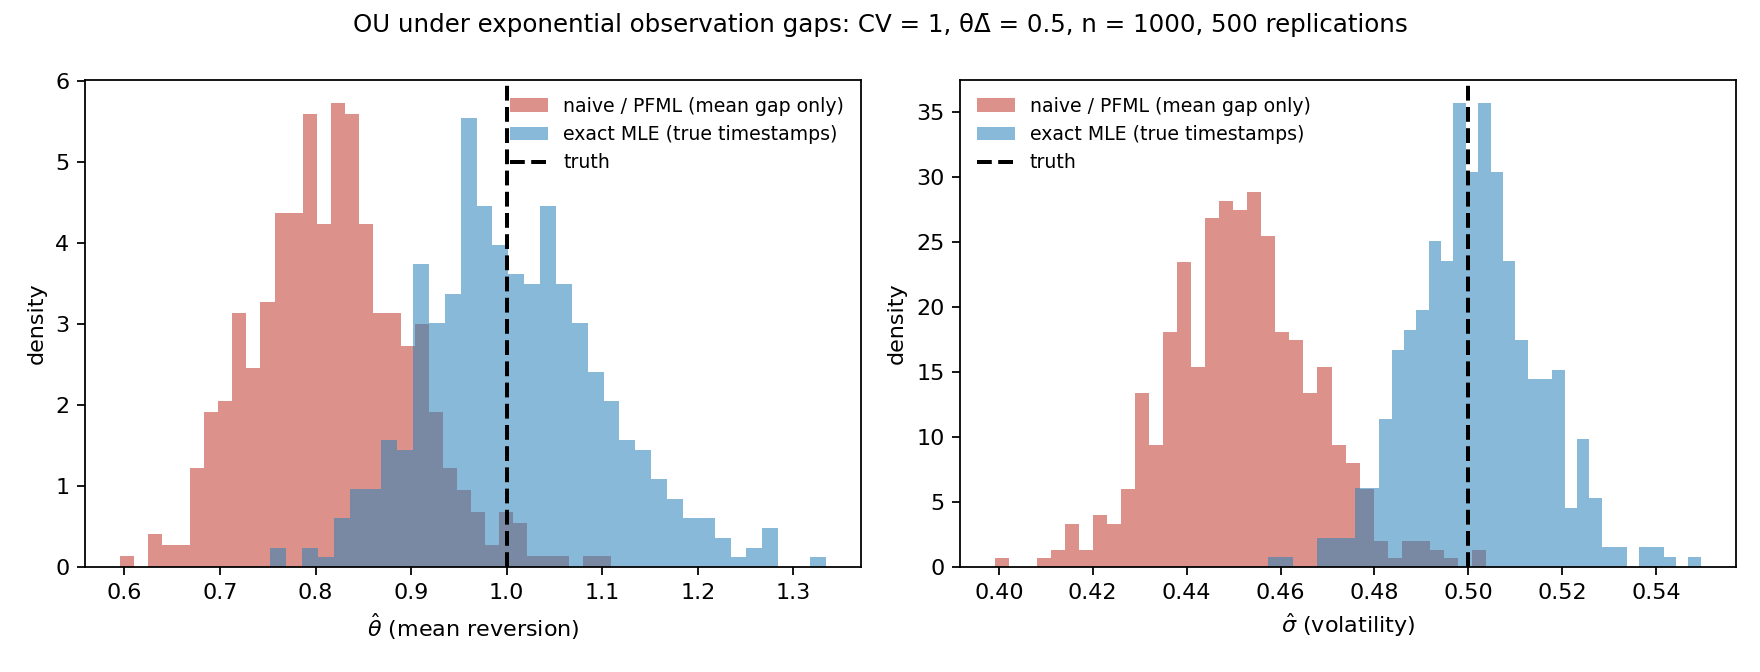

In [5]:
# Cell 4 — naive (PFML) vs exact under exponential gaps: mean_gap = 0.5 (theta*mean_gap = 0.5), n = 1000, 500 reps
rng = child["c4"]
n, mean_gap, R = 1000, 0.5, 500
rows = []
for r in range(R):
    tr = exponential_gap_times(n, mean_gap, rng)
    xr = simulate_ou(THETA, MU, SIGMA, tr, rng)
    fe = fit(ou_neg_loglik,    xr, tr)     # exact: uses the true timestamps
    fn = fit(naive_neg_loglik, xr, tr)     # naive / PFML: every gap replaced by the mean gap
    require_convergence(fe, f"exact teaser replication {r}")
    require_convergence(fn, f"PFML teaser replication {r}")
    rows.append({"rep": r,
                 **{f"{key}_exact": value for key, value in fit_record(fe).items()},
                 **{f"{key}_naive": value for key, value in fit_record(fn).items()},
                 "ok": fe["success"] and fn["success"]})
mc4 = pd.DataFrame(rows); mc4.to_csv(RESULTS / "cell4_teaser_naive_vs_exact.csv", index=False)

# analytic large-sample limit of the naive/PFML estimator under exponential gaps (Gamma with CV = 1)
th_lim, sg_lim = pfml_limit(THETA, SIGMA, mean_gap, cv=1.0)
summary = pd.DataFrame({
    "truth":        [THETA, SIGMA],
    "exact mean":   [mc4.theta_exact.mean(), mc4.sigma_exact.mean()],
    "exact SD":     [mc4.theta_exact.std(),  mc4.sigma_exact.std()],
    "naive mean":   [mc4.theta_naive.mean(), mc4.sigma_naive.mean()],
    "naive SD":     [mc4.theta_naive.std(),  mc4.sigma_naive.std()],
    "naive limit (analytic)": [th_lim, sg_lim],
}, index=["theta", "sigma"])
summary["exact rel. bias"] = summary["exact mean"] / summary["truth"] - 1
summary["naive rel. bias"] = summary["naive mean"] / summary["truth"] - 1
print(f"theta*mean_gap = {THETA*mean_gap}, CV = 1, n = {n}, {R} replications (converged: {mc4.ok.mean():.0%})")
print(summary.T.to_string(float_format=lambda v: f"{v:.4f}"))

# Checks at this setting: small observed finite-sample exact-MLE bias; expected span = 499.5.
# naive biased and consistent with its analytic limit
assert abs(summary.loc["theta", "exact rel. bias"]) < 0.04 and abs(summary.loc["sigma", "exact rel. bias"]) < 0.02
assert summary.loc["theta", "naive rel. bias"] < -0.10 and summary.loc["sigma", "naive rel. bias"] < -0.05
assert abs(mc4.theta_naive.mean() / th_lim - 1) < 0.04 and abs(mc4.sigma_naive.mean() / sg_lim - 1) < 0.03, \
    "naive Monte Carlo mean disagrees with its analytic limit"
print("\nThe residual exact-MLE bias here is small. These cells vary both mean gap and expected span,")
print("so they do not establish an isolated order-1/T scaling law or confidence-interval coverage.")
print("\nCell 4 asserts: PASS")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, key, truth, lab in [(axes[0], "theta", THETA, r"$\hat\theta$ (mean reversion)"),
                            (axes[1], "sigma", SIGMA, r"$\hat\sigma$ (volatility)")]:
    ax.hist(mc4[f"{key}_naive"], bins=35, alpha=0.55, color="#c0392b", label="naive / PFML (mean gap only)", density=True)
    ax.hist(mc4[f"{key}_exact"], bins=35, alpha=0.55, color="#2980b9", label="exact MLE (true timestamps)", density=True)
    ax.axvline(truth, color="k", lw=1.8, ls="--", label="truth")
    ax.set_xlabel(lab); ax.set_ylabel("density"); ax.legend(frameon=False, fontsize=8.5)
fig.suptitle(f"OU under exponential observation gaps: CV = 1, θΔ̄ = {THETA*mean_gap}, n = {n}, {R} replications", fontsize=11)
fig.tight_layout(); fig.savefig(FIGURES / "teaser.png", dpi=160); plt.close(fig)
display(Image(filename=str(FIGURES / "teaser.png")))

print('''Caption: Sampling distributions of the mean-reversion and volatility estimates under exponentially distributed
observation gaps (CV = 1, θΔ̄ = 0.5, n = 1000, 500 replications). The naive estimator, which uses only the average gap,
has substantial bias; the exact MLE, which uses the true timestamps, is close to the truth in this setting.
These are preliminary point-estimation results. Coverage and operating-region boundaries remain future work.''')

## Cell 5 — Week-3 preview: the Euler contrast and its analytic bias limit (not part of the Week-2 exit test)

In [6]:
# Cell 5 — Euler / Gaussian contrast on equidistant data, dt = 0.5: Monte Carlo vs analytic limit
rng = child["c5"]
n, dt, R = 1000, 0.5, 200
t = equidistant_times(n, dt)
rows = []
for r in range(R):
    xr = simulate_ou(THETA, MU, SIGMA, t, rng)
    fu = fit(euler_neg_loglik, xr, t)
    require_convergence(fu, f"Euler replication {r}")
    rows.append({"rep": r, **fit_record(fu)})
mc5 = pd.DataFrame(rows); mc5.to_csv(RESULTS / "cell5_euler_equidistant_preview.csv", index=False)
th_e, sg_e = euler_limit_equidistant(THETA, SIGMA, dt)
tab5 = pd.DataFrame({"truth": [THETA, SIGMA], "Euler MC mean": [mc5.theta.mean(), mc5.sigma.mean()],
                     "Euler MC SD": [mc5.theta.std(), mc5.sigma.std()], "Euler analytic limit": [th_e, sg_e]},
                    index=["theta", "sigma"])
tab5["rel. bias"] = tab5["Euler MC mean"] / tab5["truth"] - 1
print(f"Euler contrast, equidistant dt={dt} (theta*dt = {THETA*dt}), n={n}, {R} reps")
print(tab5.to_string(float_format=lambda v: f"{v:.4f}"))
assert abs(mc5.theta.mean() / th_e - 1) < 0.03 and abs(mc5.sigma.mean() / sg_e - 1) < 0.02, "Euler MC disagrees with analytic limit"
print("\nCell 5 asserts: PASS   (discretization bias of the Euler contrast at theta*dt = 0.5 is real and predictable)")
print(f"\nTotal notebook wall time: {time.time() - T0:.1f} s")

Euler contrast, equidistant dt=0.5 (theta*dt = 0.5), n=1000, 200 reps
       truth  Euler MC mean  Euler MC SD  Euler analytic limit  rel. bias
theta 1.0000         0.7914       0.0510                0.7869    -0.2086
sigma 0.5000         0.3973       0.0087                0.3975    -0.2055

Cell 5 asserts: PASS   (discretization bias of the Euler contrast at theta*dt = 0.5 is real and predictable)

Total notebook wall time: 31.4 s
